In [1]:
import os
import anndata as ad
import pandas as pd
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt

/Users/zoezabetian/miniconda3/envs/sims_env_310/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## For Wendering data

### Load data and view cell type labels

In [46]:
h5ad_file_path_wend_streamlined_mapped = '/Users/zoezabetian/Desktop/M-R-lab/leo_project/wend_files/Wend2024sciadv_two_labels.h5ad'
adata_wend = ad.read_h5ad(h5ad_file_path_wend_streamlined_mapped)

print(adata_wend.var.head())
# Remove the index name (label) from adata.obs
# Assuming you have already loaded adata_wend
# Remove the index name (label) from adata.obs
adata_wend.obs.index.name = None  # This will remove the "Unique_ID" label

# Assuming the column with cell type labels is named 'subset'
unique_cell_types = adata_wend.obs['treg'].unique()  # Get all unique cell type labels

# Print all unique cell type labels
print("\nUnique cell type labels:")
for cell_type in unique_cell_types:
    print(cell_type)
    
#drop "none" label
filtered_adata_wend = adata_wend[~adata_wend.obs['treg'].str.contains("none", na=False)].copy() # filter out "none" cells

Empty DataFrame
Columns: []
Index: [MIR1302-2HG, FAM138A, OR4F5, LINC01409, FAM87B]

Unique cell type labels:
Teffector
Treg


/Users/zoezabetian/miniconda3/envs/sims_env_310/lib/python3.9/site-packages/anndata/_core/anndata.py:1832: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


### View shape, .obs, and .var

In [18]:
# Shape of the dataset (cells x genes)
print(f"Dataset shape: {filtered_adata_wend.shape}")

# Summary of observations (cells)
print("\nObservations (metadata):")
print(filtered_adata_wend.obs.head())

# Summary of variables (genes)
print("\nVariables (genes):")
print(filtered_adata_wend.var.head())


Dataset shape: (19386, 23645)

Observations (metadata):
                               treg
CoTP8_ACTTGTTCACAGAGGT-1  Teffector
CoTP8_ACACCCTAGCGTAATA-1       Treg
CoTP2_TTCTCAAAGACCACGA-1       Treg
CoTP8_CTCTAATTCACGATGT-1  Teffector
CoTP4_AAGGCAGAGGTGATAT-1       Treg

Variables (genes):
Empty DataFrame
Columns: []
Index: [MIR1302-2HG, FAM138A, OR4F5, LINC01409, FAM87B]


### Get cell counts and plot distribution


Cell type distribution:
treg
Teffector    11081
Treg          8305
Name: count, dtype: int64


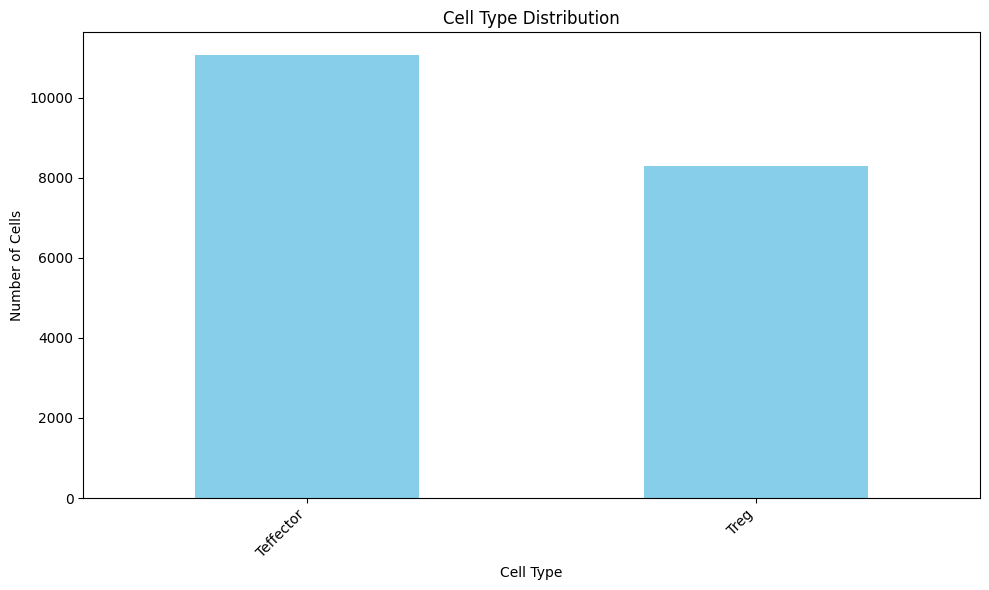

In [20]:
# Count cells by type
cell_type_counts = filtered_adata_wend.obs['treg'].value_counts()
print("\nCell type distribution:")
print(cell_type_counts)

plt.figure(figsize=(10, 6))
cell_type_counts.plot(kind='bar', color='skyblue')
plt.title("Cell Type Distribution")
plt.xlabel("Cell Type")
plt.ylabel("Number of Cells")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()



Total counts per cell:
count    19386.000000
mean      3981.813370
std       1779.517705
min       1602.000000
25%       3053.000000
50%       3620.000000
75%       4358.000000
max      33003.000000
Name: total_counts, dtype: float64


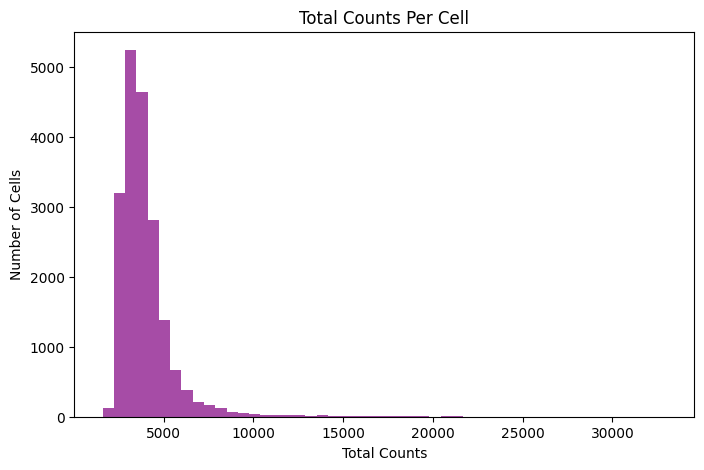

In [21]:
# Summarize total counts per cell
filtered_adata_wend.obs['total_counts'] = filtered_adata_wend.X.sum(axis=1).A1  # Use .A1 to convert sparse to dense if needed
print("\nTotal counts per cell:")
print(filtered_adata_wend.obs['total_counts'].describe())

# Plot distribution of total counts
plt.figure(figsize=(8, 5))
plt.hist(filtered_adata_wend.obs['total_counts'], bins=50, color='purple', alpha=0.7)
plt.title("Total Counts Per Cell")
plt.xlabel("Total Counts")
plt.ylabel("Number of Cells")
plt.show()


### Get mean and highly expressed genes


Top 10 highly expressed genes:
        mean_expression
EEF1A1        85.813680
MALAT1        73.957134
B2M           68.354070
RPL10         58.227742
RPS12         54.383782
RPL41         53.254256
RPLP1         48.351388
RPL13         42.079851
RPL32         40.874136
RPL30         39.733725


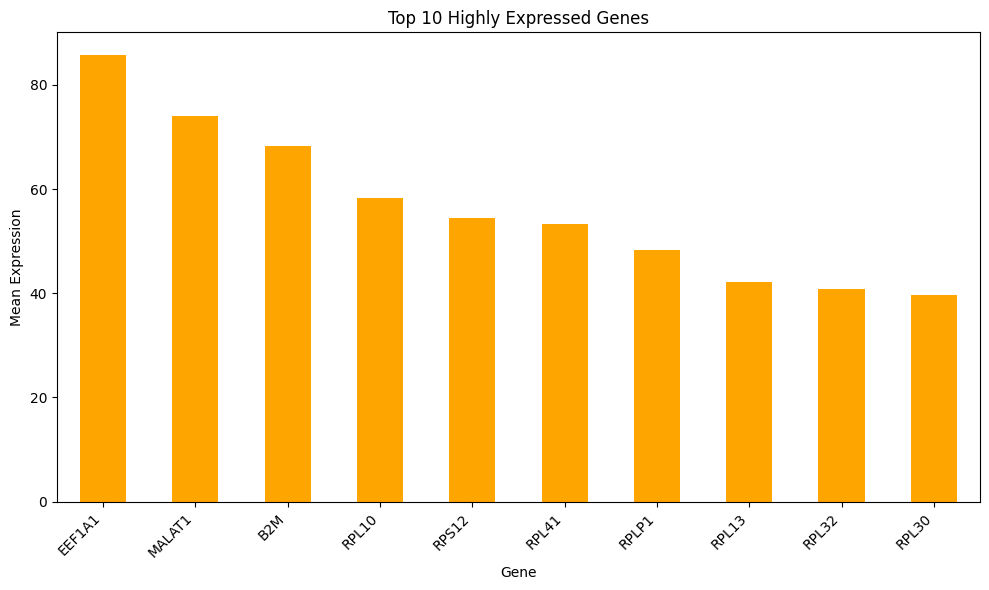

In [22]:
# Calculate mean expression for each gene
mean_expression = np.array(filtered_adata_wend.X.mean(axis=0)).flatten()
filtered_adata_wend.var['mean_expression'] = mean_expression

# Top 10 highly expressed genes
top_genes = filtered_adata_wend.var.sort_values('mean_expression', ascending=False).head(10)
print("\nTop 10 highly expressed genes:")
print(top_genes[['mean_expression']])

# Plot top 10 genes
plt.figure(figsize=(10, 6))
top_genes['mean_expression'].plot(kind='bar', color='orange')
plt.title("Top 10 Highly Expressed Genes")
plt.xlabel("Gene")
plt.ylabel("Mean Expression")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


### Convert sparse matrix to dense and int to float

In [47]:
# Convert to dense if sparse, then to float
if not isinstance(filtered_adata_wend.X, np.ndarray):
    print("Converting sparse matrix to dense format...")
    filtered_adata_wend.X = filtered_adata_wend.X.toarray()

# Convert data to float
if not np.issubdtype(filtered_adata_wend.X.dtype, np.floating):
    print("Converting data to float...")
    filtered_adata_wend.X = filtered_adata_wend.X.astype(np.float32)


Converting sparse matrix to dense format...
Converting data to float...


### Perform PCA

In [48]:
print("Computing PCA...")
sc.tl.pca(filtered_adata_wend, n_comps=50)  # Use 50 principal components (or adjust as needed)

# Use PCA for neighbors and UMAP
print("Computing neighbors and UMAP...")
sc.pp.neighbors(filtered_adata_wend, n_neighbors=15, use_rep="X_pca")
sc.tl.umap(filtered_adata_wend)

Computing PCA...
Computing neighbors and UMAP...


### Plot UMAP

/Users/zoezabetian/miniconda3/envs/sims_env_310/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


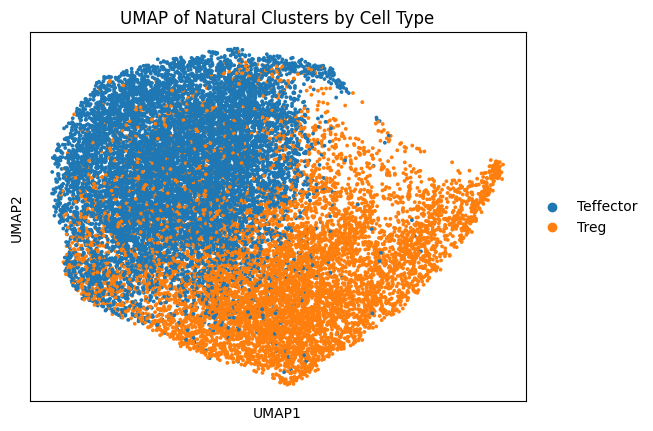

In [60]:
sc.pl.umap(
    filtered_adata_wend,
    color='treg',
    title='UMAP of Natural Clusters by Cell Type',
    size=30
)


## For Luo data: 

code for viewing Luo's manual clusters by gene with NA dropped for comparison:

/Users/zoezabetian/miniconda3/envs/sims_env_310/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


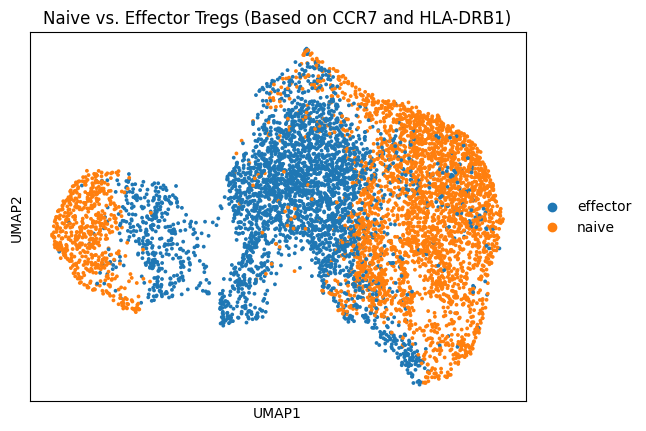

In [59]:
h5ad_file_path_luo = '/Users/zoezabetian/Desktop/M-R-lab/leo_project/luo_files/Luo2021nature_new_labels.h5ad'
adata_luo = ad.read_h5ad(h5ad_file_path_luo)

print(adata_luo.var.head())
# Remove the index name (label) from adata.obs
# Assuming you have already loaded adata_wend
# Remove the index name (label) from adata.obs
adata_luo.obs.index.name = None  # This will remove the "Unique_ID" label

# Assuming the column with cell type labels is named 'subset'
unique_cell_types = adata_luo.obs['treg'].unique()  # Get all unique cell type labels

# Print all unique cell type labels
print("\nUnique cell type labels:")
for cell_type in unique_cell_types:
    print(cell_type)
    
#drop "none" label
filtered_adata_luo = adata_luo[~adata_luo.obs['treg'].str.contains("none", na=False)].copy() # filter out "none" cells

# Convert to dense if sparse, then to float
if not isinstance(filtered_adata_luo.X, np.ndarray):
    print("Converting sparse matrix to dense format...")
    filtered_adata_luo.X = filtered_adata_luo.X.toarray()

# Convert data to float
if not np.issubdtype(filtered_adata_luo.X.dtype, np.floating):
    print("Converting data to float...")
    filtered_adata_luo.X = filtered_adata_luo.X.astype(np.float32)

print("Computing PCA...")
sc.tl.pca(filtered_adata_luo, n_comps=50)  # Use 50 principal components (or adjust as needed)

# Use PCA for neighbors and UMAP
print("Computing neighbors and UMAP...")
sc.pp.neighbors(filtered_adata_luo, n_neighbors=15, use_rep="X_pca")
sc.tl.umap(filtered_adata_luo)

sc.pl.umap(
    filtered_adata_luo,
    color='treg',
    title='Naive vs. Effector Tregs (Based on CCR7 and HLA-DRB1)',
    size=30
)


In [52]:
h5ad_file_path_luo = '/Users/zoezabetian/Desktop/M-R-lab/leo_project/luo_files/Luo2021nature_cleaned.h5ad'
adata_luo = sc.read_h5ad(h5ad_file_path_luo)
print(adata_luo.obs.head())


                   labels
AAACCTGAGAAACCGC_6   PB_2
AAACCTGAGACACTAA_7   PB_2
AAACCTGAGACAGGCT_7   PB_2
AAACCTGAGACCTTTG_6   PB_2
AAACCTGAGACGCTTT_5   PB_1


/Users/zoezabetian/miniconda3/envs/sims_env_310/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


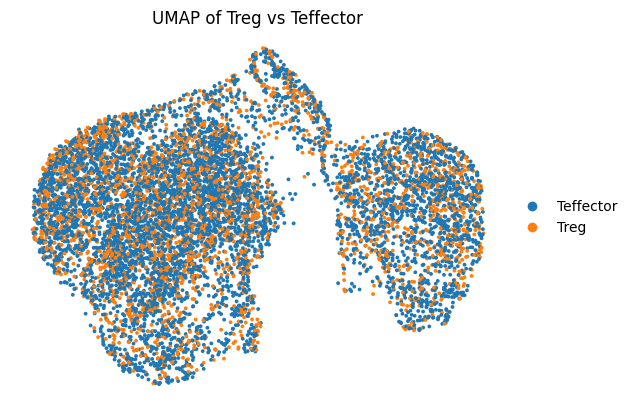

In [57]:
import scanpy as sc

# Define cluster mapping
cluster_mapping = {
    'PB_0': 'Treg', 'PB_3': 'Treg', 'PB_5': 'Treg',
    'PB_1': 'Teffector', 'PB_2': 'Teffector', 'PB_4': 'Teffector',
    'PB_6': 'Teffector', 'PB_7': 'Teffector', 'PB_8': 'Teffector'
}

# Apply the mapping to the 'leiden' column (or relevant column for your clusters)
adata_luo.obs['treg_label'] = adata_luo.obs['labels'].map(cluster_mapping)

# Filter out rows with unmapped values (e.g., clusters not in the mapping)
adata_luo_filtered = adata_luo[adata_luo.obs['treg_label'].notna()].copy()

# Verify mapping and filtering
print("Cluster mapping applied:")
print(adata_luo_filtered.obs['treg_label'].value_counts())

# Compute PCA (required for neighbors and UMAP)
print("Computing PCA...")
sc.pp.pca(adata_luo_filtered, n_comps=50)  # Compute PCA with 50 components

# Run neighbors and UMAP on the filtered dataset
sc.pp.neighbors(adata_luo_filtered, use_rep='X_pca')  # Use the PCA-transformed space
sc.tl.umap(adata_luo_filtered)

# Visualize UMAP
sc.pl.umap(
    adata_luo_filtered,
    color='treg_label',
    title='UMAP of Treg vs Teffector',
    legend_loc='right margin',
    size=30,
    frameon=False
)
